# 03 · Affordability Analysis

This notebook covers the third phase of the Barcelona Housing Affordability Analysis:

- District-level affordability overview
- Neighbourhood-level deep dive
- Evolution of affordability over time (2018–2022)
- Relationship between income, cadastral value and dwelling size

**Input:** `data/processed/master_dataset.csv`  
**Output:** Visualisations saved to `visualizations/`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
VIZ       = ROOT / "visualizations"
VIZ.mkdir(exist_ok=True)

df = pd.read_csv(PROCESSED / "master_dataset.csv")

print(f"Shape  : {df.shape}")
print(f"Period : {df['year'].min()} — {df['year'].max()}")
print(f"Columns: {list(df.columns)}")

Shape  : (5340, 13)
Period : 2018 — 2022
Columns: ['year', 'district_id', 'district_name', 'neighbourhood_id', 'neighbourhood_name', 'census_section', 'unit_cadastral_value', 'income_per_capita', 'total_dwellings', 'small_dwellings', 'pct_small_dwellings', 'affordability_ratio', 'affordability_category']


## 1. District-Level Affordability Overview (2022)

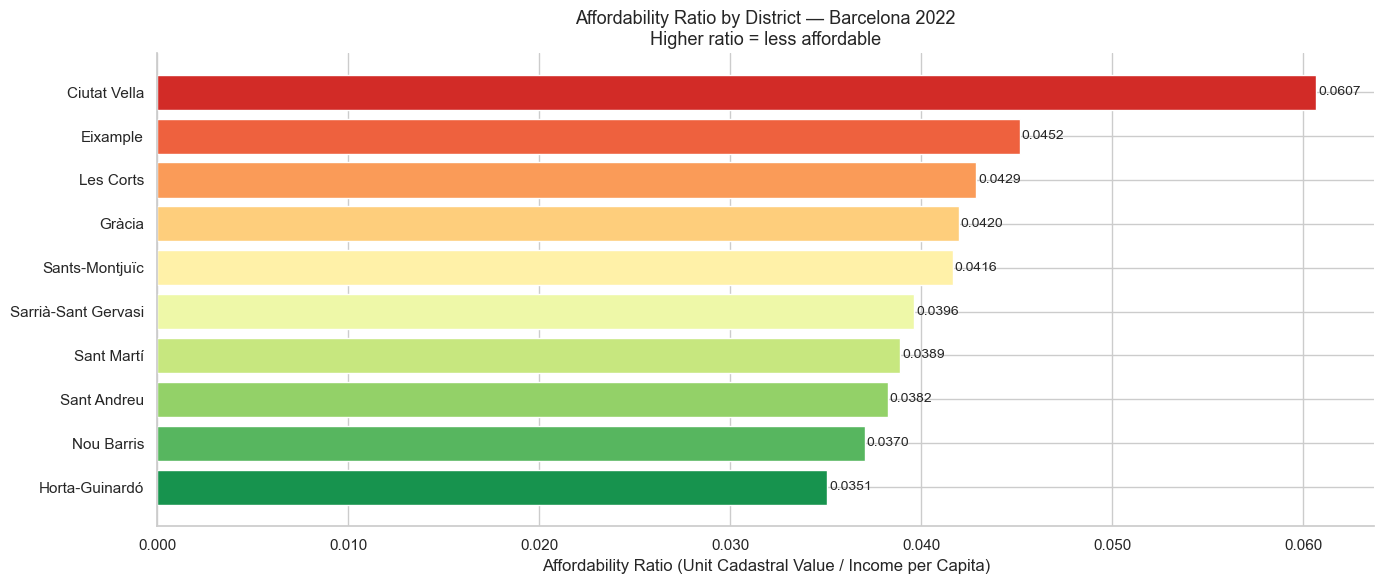

Plot saved.


In [50]:
df_2022 = df[df['year'] == 2022]

district_summary = (
    df_2022.groupby('district_name')
    .agg(
        avg_unit_value      = ('unit_cadastral_value', 'mean'),
        avg_income          = ('income_per_capita', 'mean'),
        affordability_ratio = ('affordability_ratio', 'mean')
    )
    .sort_values('affordability_ratio', ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(district_summary['district_name'], 
               district_summary['affordability_ratio'],
               color=sns.color_palette('RdYlGn_r', len(district_summary)))

ax.set_xlabel('Affordability Ratio (Unit Cadastral Value / Income per Capita)')
ax.set_title('Affordability Ratio by District — Barcelona 2022\n'
             'Higher ratio = less affordable', fontsize=13)

for bar, val in zip(bars, district_summary['affordability_ratio']):
    ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.savefig(VIZ / '01_affordability_ratio_by_district.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 2. Income vs Cadastral Value by District (2022)

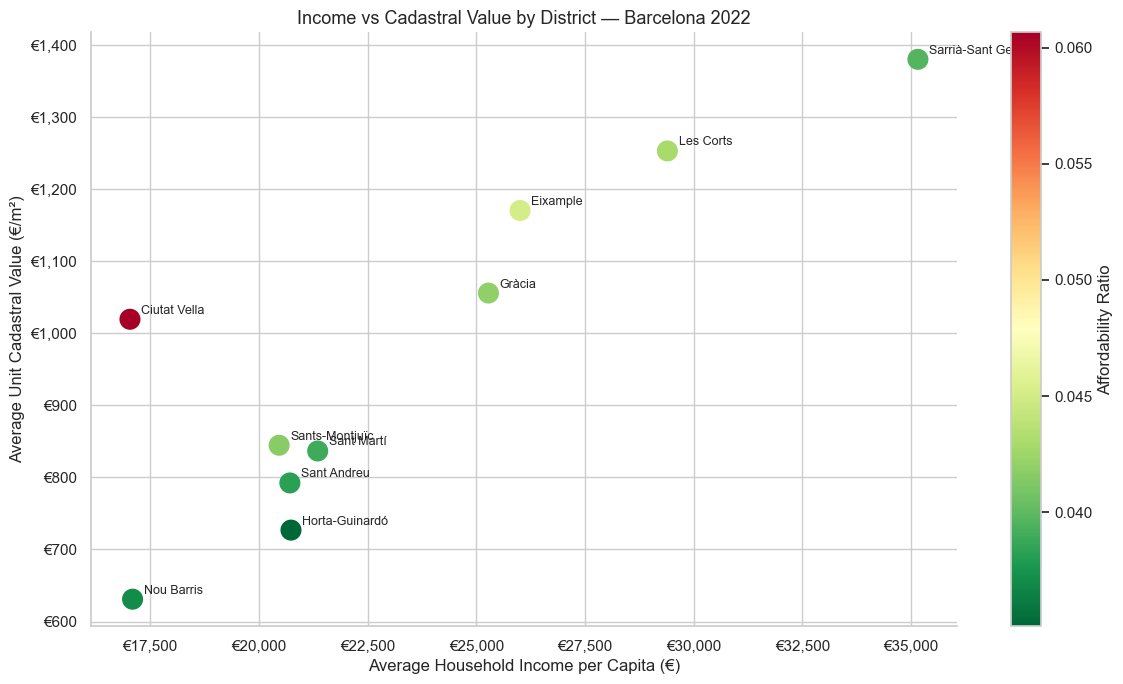

Plot saved.


In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    district_summary['avg_income'],
    district_summary['avg_unit_value'],
    s=200,
    c=district_summary['affordability_ratio'],
    cmap='RdYlGn_r',
    zorder=3
)

# Label each point
for _, row in district_summary.iterrows():
    ax.annotate(row['district_name'],
                xy=(row['avg_income'], row['avg_unit_value']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=9)

plt.colorbar(scatter, label='Affordability Ratio')
ax.set_xlabel('Average Household Income per Capita (€)')
ax.set_ylabel('Average Unit Cadastral Value (€/m²)')
ax.set_title('Income vs Cadastral Value by District — Barcelona 2022', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

plt.tight_layout()
plt.savefig(VIZ / '02_income_vs_cadastral_value.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 3. Small Dwellings vs Affordability (2022)

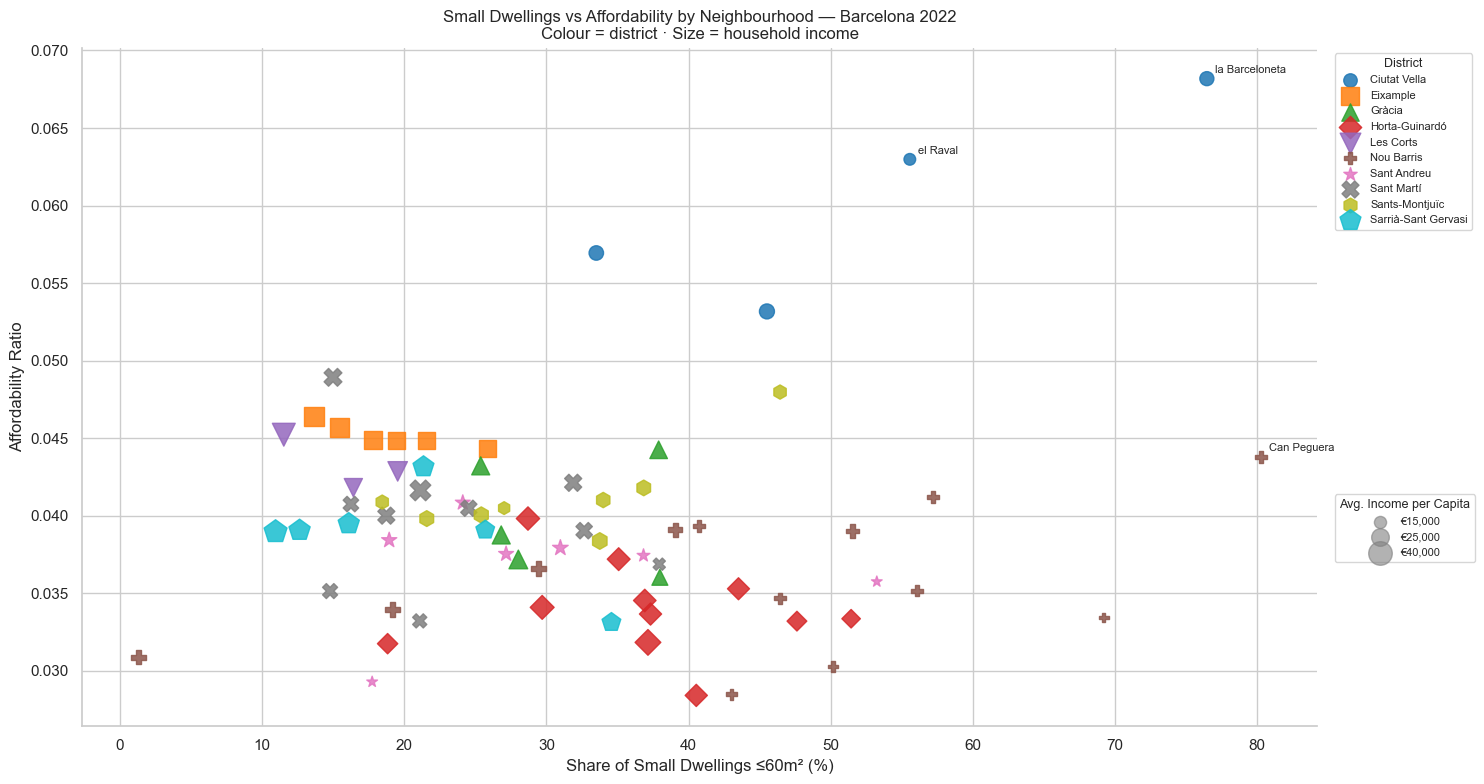

Plot saved.


In [29]:
fig, ax = plt.subplots(figsize=(15, 8))

districts = sorted(neighbourhood_2022['district_name'].unique())
colors = sns.color_palette('tab10', len(districts))
district_color = dict(zip(districts, colors))
markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']
district_marker = dict(zip(districts, markers))

# Normalise income to marker size range [50, 300]
income_min = neighbourhood_2022['avg_income'].min()
income_max = neighbourhood_2022['avg_income'].max()
neighbourhood_2022 = neighbourhood_2022.copy()
neighbourhood_2022['marker_size'] = (
    50 + 250 * (neighbourhood_2022['avg_income'] - income_min) / (income_max - income_min)
)

for district, group in neighbourhood_2022.groupby('district_name'):
    ax.scatter(
        group['pct_small_dwellings'],
        group['affordability_ratio'],
        c=[district_color[district]],
        s=group['marker_size'],
        alpha=0.85,
        marker=district_marker[district],
        label=district,
        zorder=3
    )

# Highlight extreme cases
extremes = neighbourhood_2022[
    (neighbourhood_2022['pct_small_dwellings'] > 70) |
    (neighbourhood_2022['affordability_ratio'] > 0.060)
]
for _, row in extremes.iterrows():
    ax.annotate(row['neighbourhood_name'],
                xy=(row['pct_small_dwellings'], row['affordability_ratio']),
                xytext=(6, 4), textcoords='offset points', fontsize=8)

# Legend 1 — districts
district_legend = ax.legend(
    bbox_to_anchor=(1.01, 1), loc='upper left',
    fontsize=8, title='District', title_fontsize=9
)
ax.add_artist(district_legend)

# Legend 2 — income size
size_handles = []
for income, label in [(15000, '€15,000'), (25000, '€25,000'), (40000, '€40,000')]:
    size = 50 + 250 * (income - income_min) / (income_max - income_min)
    size_handles.append(
        plt.scatter([], [], c='grey', alpha=0.6, s=size, label=label)
    )
ax.legend(handles=size_handles, bbox_to_anchor=(1.01, 0.35),
          loc='upper left', fontsize=8,
          title='Avg. Income per Capita', title_fontsize=9)

ax.set_xlabel('Share of Small Dwellings ≤60m² (%)')
ax.set_ylabel('Affordability Ratio')
ax.set_title('Small Dwellings vs Affordability by Neighbourhood — Barcelona 2022\n'
             'Colour = district · Size = household income', fontsize=12)

plt.tight_layout()
plt.savefig(VIZ / '03_small_dwellings_vs_affordability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 4. Evolution of Affordability Over Time (2018–2022)

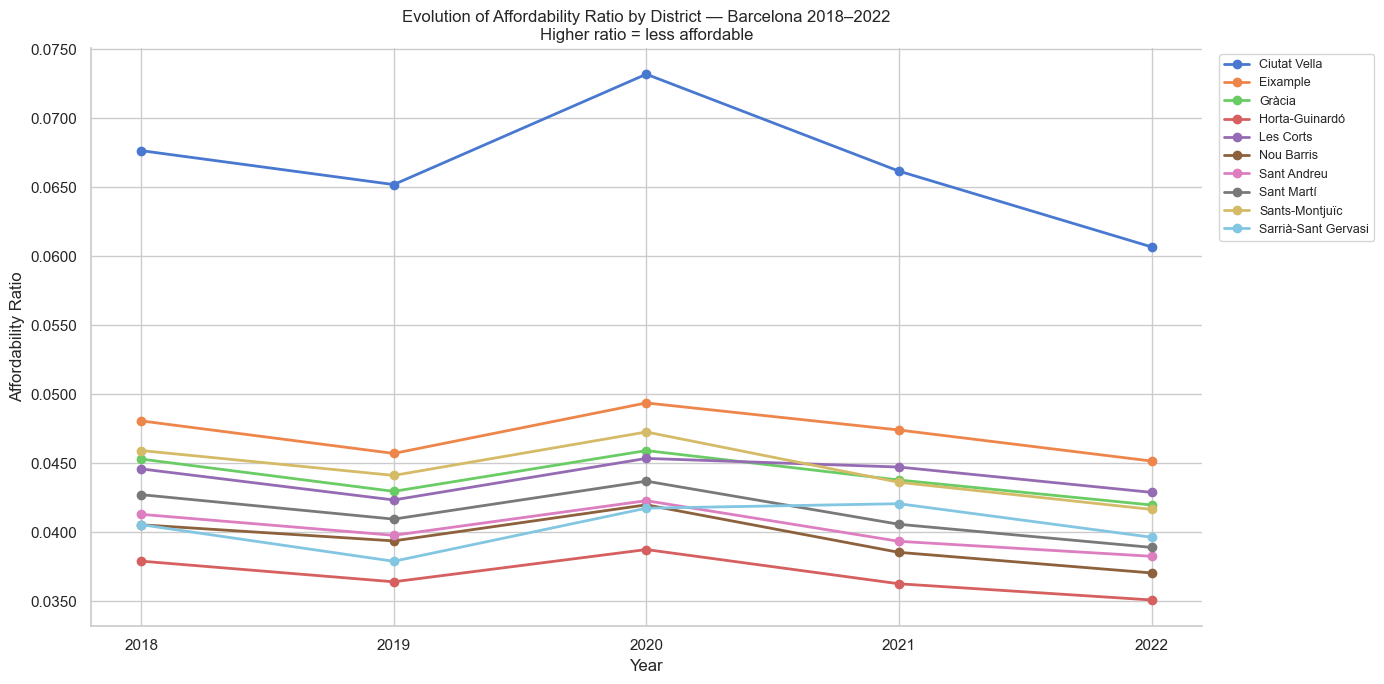

Plot saved.


In [32]:
district_evolution = (
    df.groupby(['year', 'district_name'])
    ['affordability_ratio'].mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))

for district, group in district_evolution.groupby('district_name'):
    ax.plot(group['year'], group['affordability_ratio'],
            marker='o', linewidth=2, label=district)

ax.set_xlabel('Year')
ax.set_ylabel('Affordability Ratio')
ax.set_title('Evolution of Affordability Ratio by District — Barcelona 2018–2022\n'
             'Higher ratio = less affordable', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
ax.set_xticks([2018, 2019, 2020, 2021, 2022])

plt.tight_layout()
plt.savefig(VIZ / '04_affordability_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 5. Top 10 Least Affordable Neighbourhoods (2022)

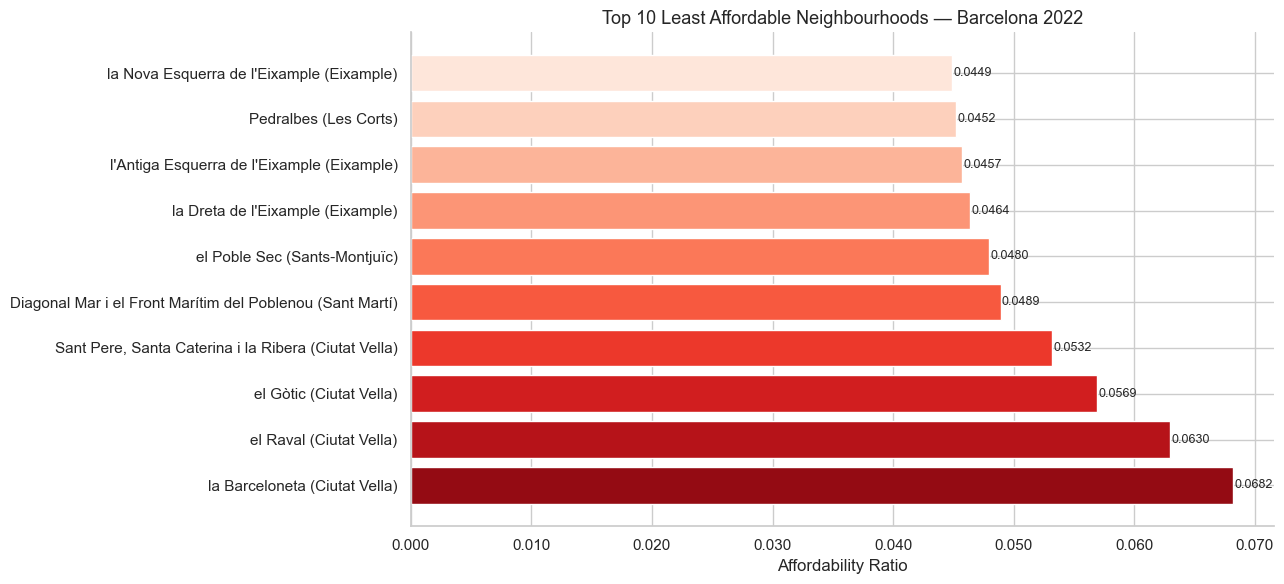

Plot saved.


In [35]:
top10_least = (
    neighbourhood_2022
    .sort_values('affordability_ratio', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(
    top10_least['neighbourhood_name'] + ' (' + top10_least['district_name'] + ')',
    top10_least['affordability_ratio'],
    color=sns.color_palette('Reds_r', 10)
)

for bar, val in zip(bars, top10_least['affordability_ratio']):
    ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Affordability Ratio')
ax.set_title('Top 10 Least Affordable Neighbourhoods — Barcelona 2022', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.savefig(VIZ / '05_top10_least_affordable.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 6. Income Distribution by Affordability Category (2022)

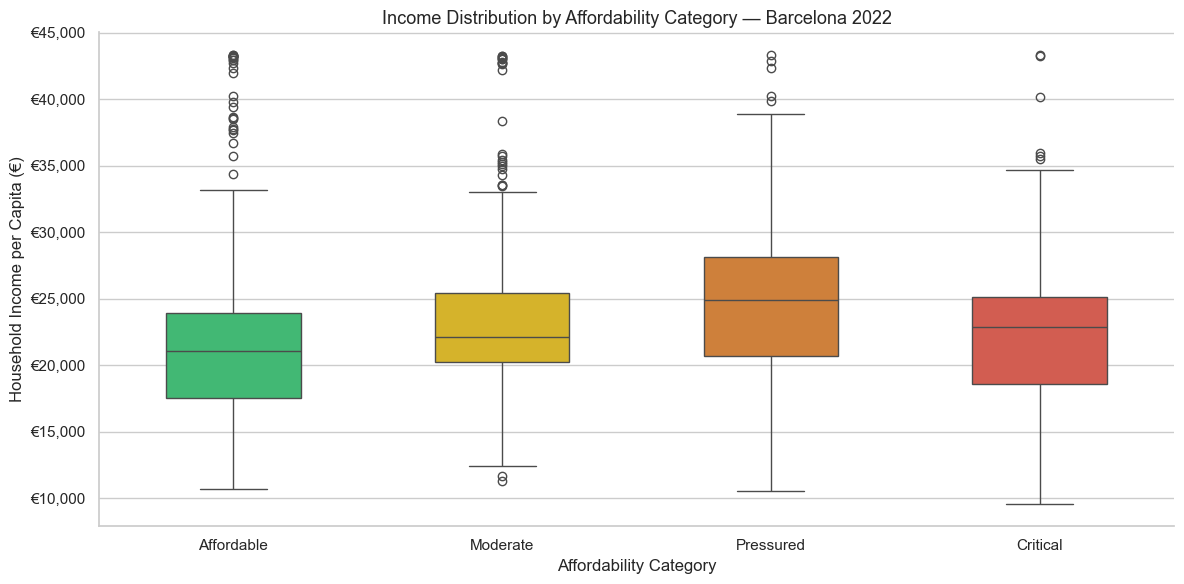

Plot saved.


In [40]:
df_2022_cat = df[df['year'] == 2022].copy()

fig, ax = plt.subplots(figsize=(12, 6))

order = ['Affordable', 'Moderate', 'Pressured', 'Critical']
palette = {'Affordable': '#2ecc71', 'Moderate': '#f1c40f',
           'Pressured': '#e67e22', 'Critical': '#e74c3c'}

sns.boxplot(data=df_2022_cat, x='affordability_category', y='income_per_capita',
            order=order, palette=palette, hue='affordability_category',
            legend=False, ax=ax, width=0.5)

ax.set_xlabel('Affordability Category')
ax.set_ylabel('Household Income per Capita (€)')
ax.set_title('Income Distribution by Affordability Category — Barcelona 2022', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

plt.tight_layout()
plt.savefig(VIZ / '06_income_by_affordability_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 7. Affordability Category Map by Neighbourhood (2022)

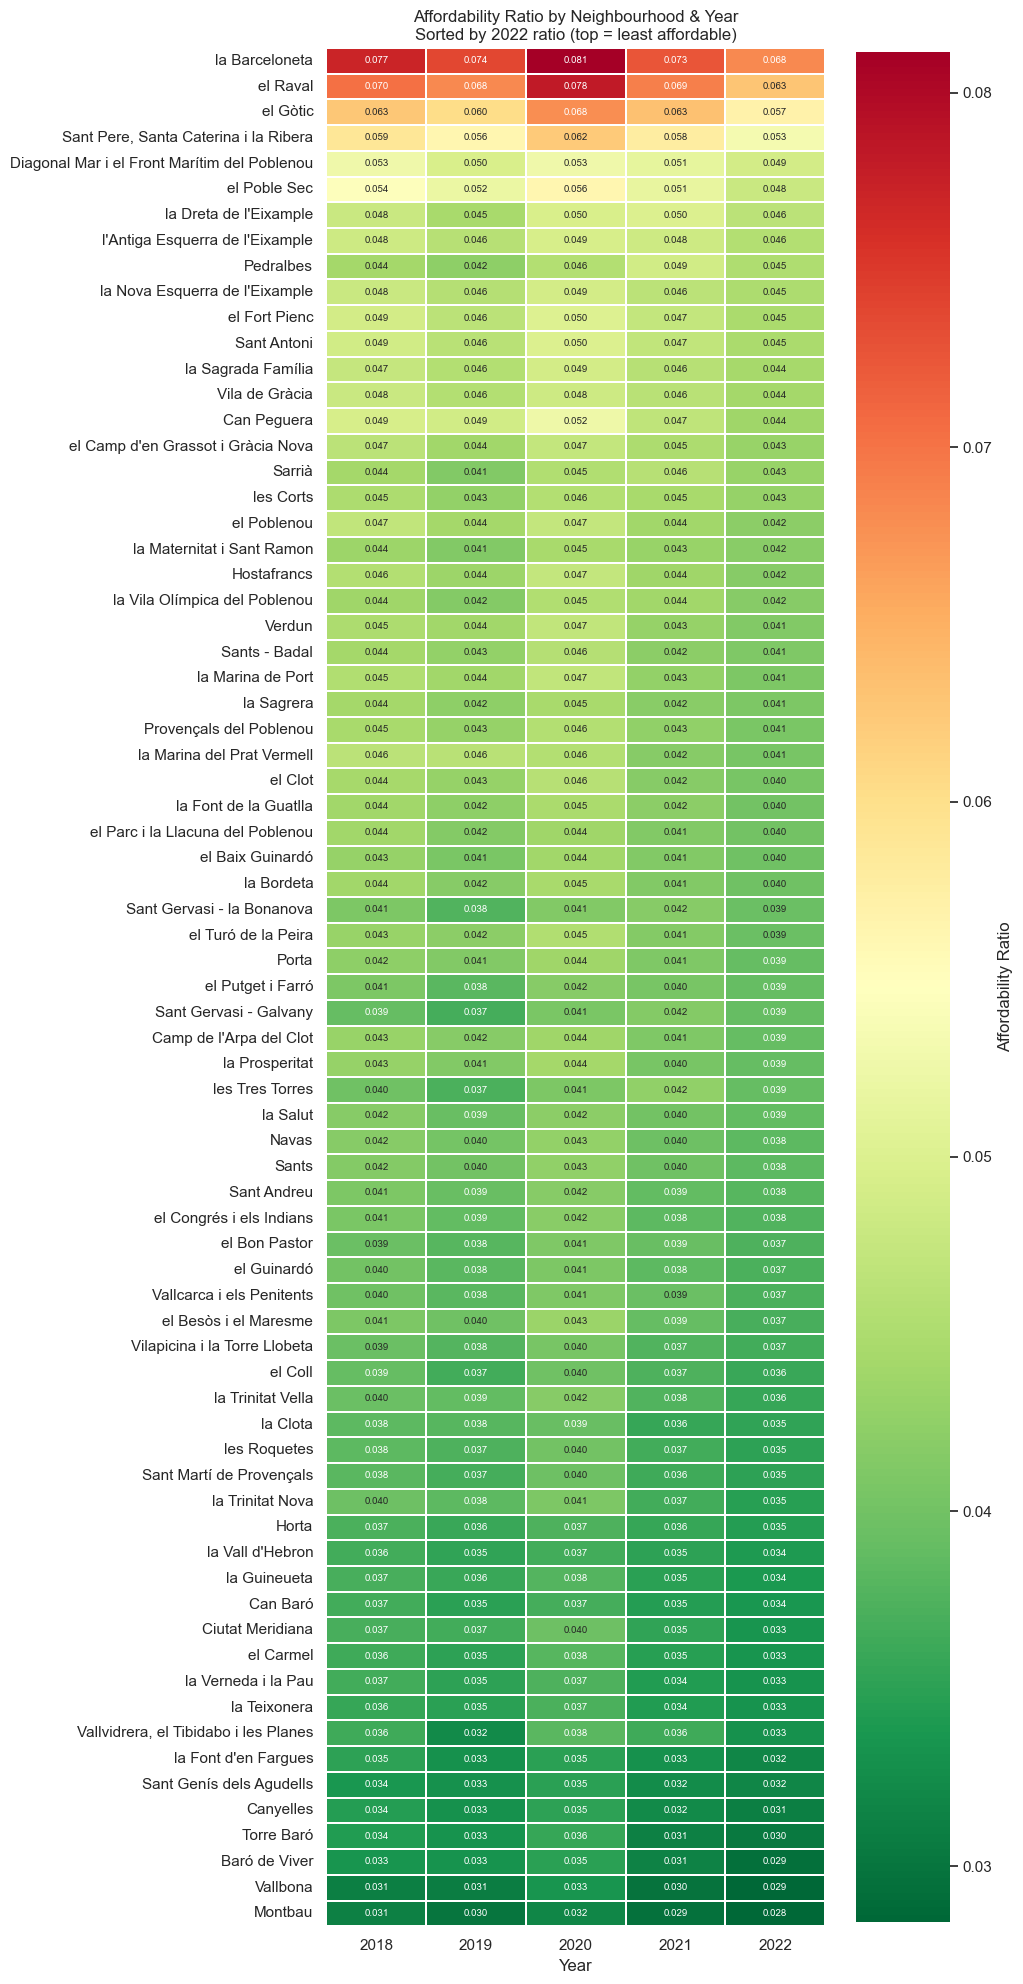

Plot saved.


In [43]:
# Pivot: neighbourhood vs year, values = mean affordability ratio
pivot = (
    df.groupby(['neighbourhood_name', 'year'])['affordability_ratio']
    .mean()
    .unstack('year')
)
pivot = pivot.sort_values(2022, ascending=False)

fig, ax = plt.subplots(figsize=(10, 20))
sns.heatmap(pivot, cmap='RdYlGn_r', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Affordability Ratio'},
            fmt='.3f', annot=True, annot_kws={'size': 7})

ax.set_title('Affordability Ratio by Neighbourhood & Year\n'
             'Sorted by 2022 ratio (top = least affordable)', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(VIZ / '07_affordability_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 8. Summary

### Key findings

**Ciutat Vella is the least affordable district by a significant margin.**  
With an affordability ratio of 0.061 in 2022, it stands well above the rest. La Barceloneta (0.068) and el Raval (0.063) are the two least affordable neighbourhoods in the city.

**The COVID-19 effect is visible in the data.**  
All districts show a peak in affordability ratio in 2020, driven by income falling faster than cadastral values during the pandemic. Ciutat Vella was the most affected, reaching 0.073 that year.

**"Affordable" does not mean high income.**  
The most affordable census sections have the lowest median income (~€21,000). Affordability here reflects low cadastral values, not purchasing power — an important methodological distinction.

**Small dwellings and low affordability are structurally linked.**  
La Barceloneta combines the highest affordability ratio (0.068) with the highest share of small dwellings (80%). The pattern holds across the city: districts with more small dwellings tend to face greater affordability pressure.

**The inequality is persistent across all five years analysed (2018–2022).**  
The ranking of neighbourhoods by affordability ratio barely changed over the period, confirming this is a structural feature, not a cyclical trend.

### Next steps
- `04_clustering.ipynb` — K-Means clustering of neighbourhoods by affordability profile